# Moment-of-symmetry scales, and finding them in a biosignal

A **moment of symmetry** (MOS), equivalently a **well-formed** scale, is built by
stacking a single generating interval and reducing by a period. It has exactly two
step sizes, large and small, distributed as evenly as two sizes can be. Almost every
scale anyone actually plays is one — the pentatonic, the diatonic, the chromatic —
plus a large microtonal hinterland ordinary keyboards cannot reach.

This notebook works through `biotuner.mos`, which implements

> Milne, A.J., Carlé, M., Sethares, W.A., Noll, T., Holland, S. (2011).
> *Scratching the Scale Labyrinth.* In Mathematics and Computation in Music,
> LNAI 6726, 180–195.

— the combinatorics, the labyrinth visualisation, the modal algebra, the Fourier
Scratching performance technique and the Dynamic Tonality timbre matching — and then
goes past the paper to the question it does not ask: **given a biosignal's spectral
peaks, which well-formed scale best explains them?**

In [1]:
# Render figures inline whatever backend the environment picked. A docs
# build with MPLBACKEND=Agg makes plt.show() a no-op, which drops every
# figure out of this notebook and leaves the prose describing nothing.
%matplotlib inline

import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import biotuner.mos as M

FIFTH = 3 / 2
plt.rcParams["figure.dpi"] = 100

C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\epic-morse-ded0d5\biotuner\biotuner_object.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


## 1. The labyrinth

The whole universe of well-formed scales, drawn at once. Reading it (Milne et al. §4):

- **angle** is the generator as a fraction of the period. Zero is at the top, ½ at the
  bottom, so a 700-cent generator against a 1200-cent period sits at 7/12 of the way round.
- **ring** is cardinality. Ring *N* carries every *N*-note MOS.
- **spokes** are equal temperaments. Each runs inward from the rim and *touches without
  crossing* the ring giving its note count.
- **arcs** are valid tuning ranges — the generators over which a scale keeps its identity.
  The thick inner band is where it is also *coherent* (proper).

The picture is left–right symmetric because a generator and its complement within the
period build the same scale.

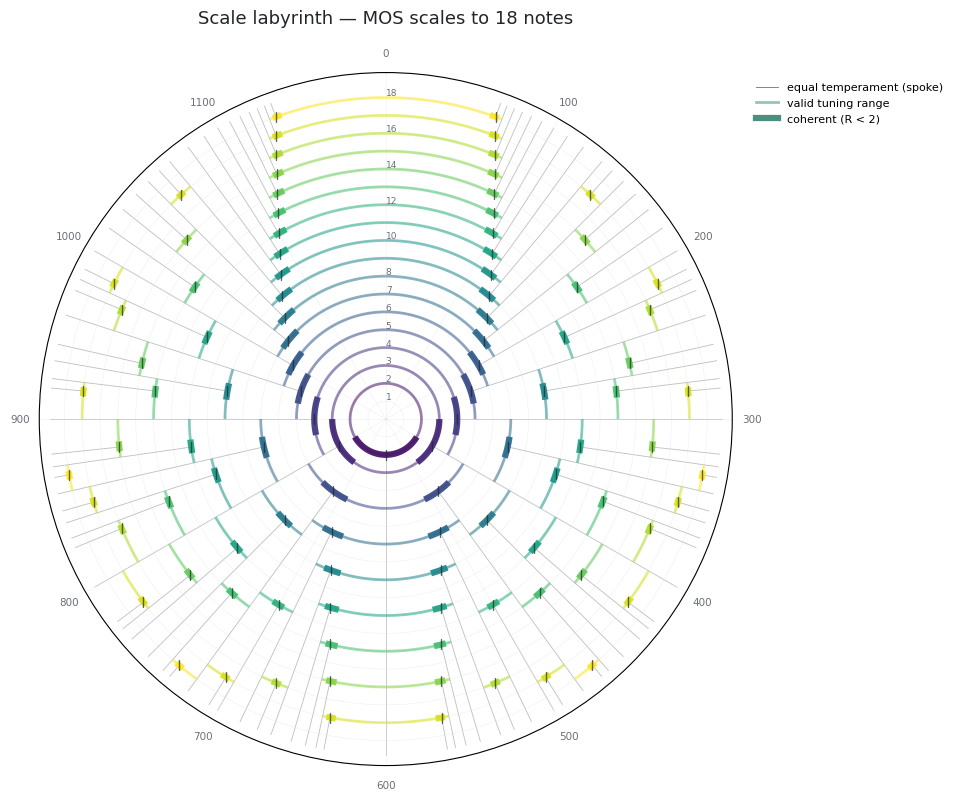

In [2]:
fig, ax = M.plot_labyrinth(18)
plt.show()

### Zooming in on the diatonic

Milne et al. Fig. 6 zooms on the 700-cent region to read off one scale's structure.
On ring 7, the arc runs from 600 ¢ (=1/2) to 720 ¢ (=3/5), and the 7-EDO spoke at
685.7 ¢ (=4/7) meets it without crossing — that is where the diatonic meets its
inverse, the anti-diatonic.

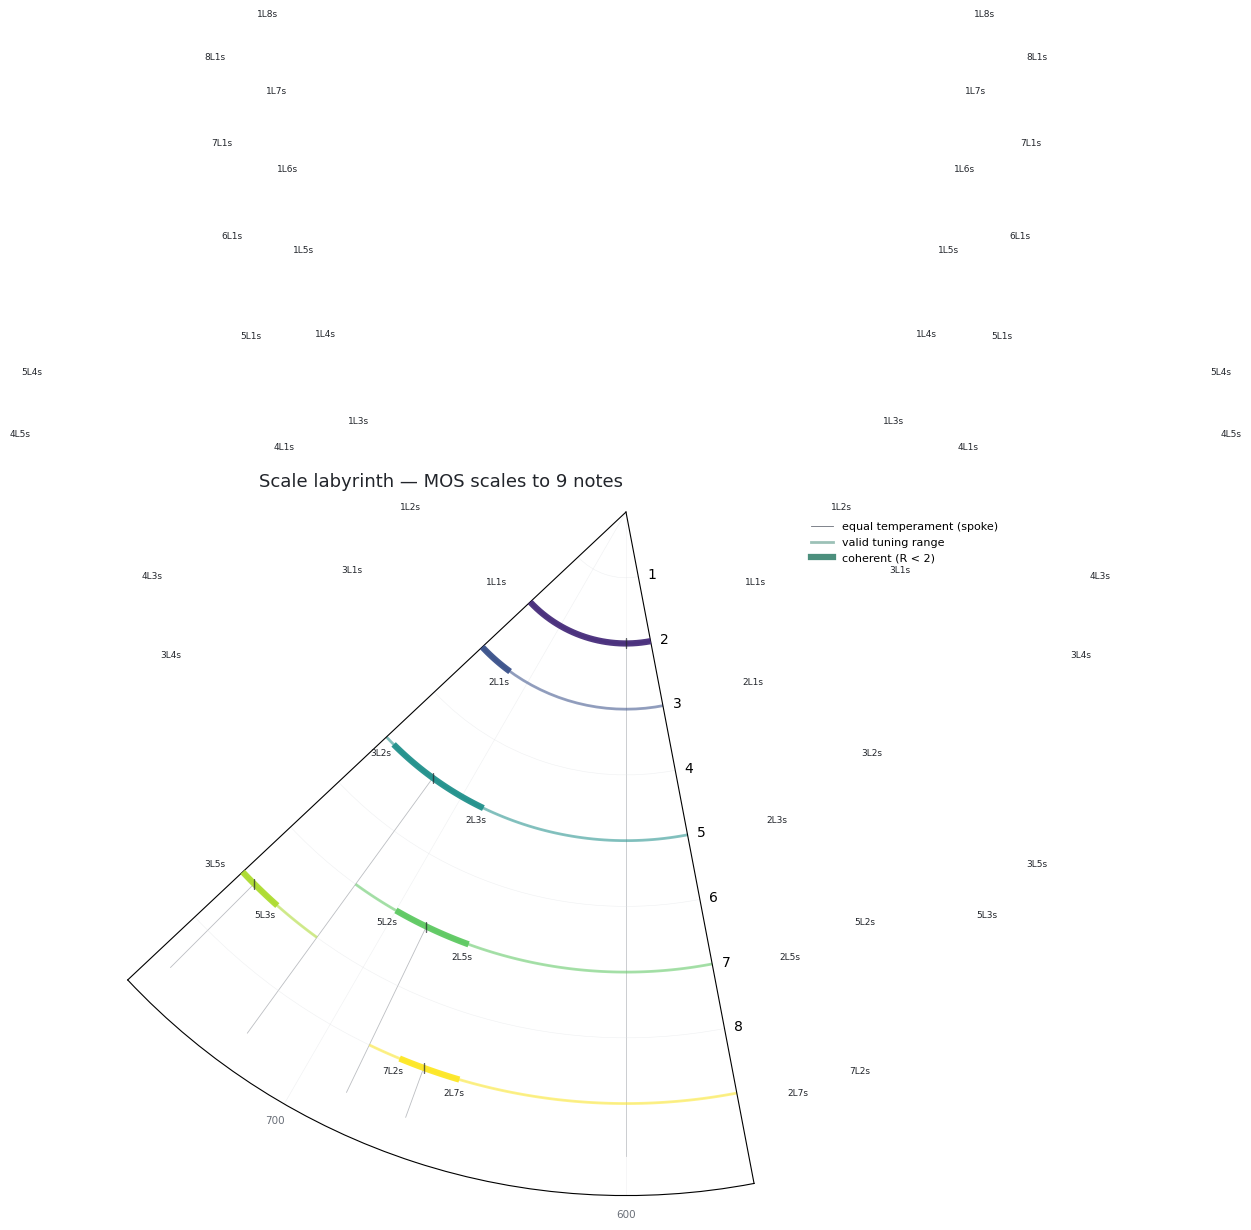

In [3]:
fig, ax = M.plot_labyrinth(9, annotate=9, generator_range=(0.47, 0.63))
plt.show()

## 2. The tree underneath

The labyrinth is a Stern–Brocot tree bent into a circle. Every node is the mediant of
the pair bracketing it, and its denominator is the cardinality of the MOS whose two step
sizes equalise there. Tracing a generator's path down the tree enumerates its entire
scale family — exactly, with no search.

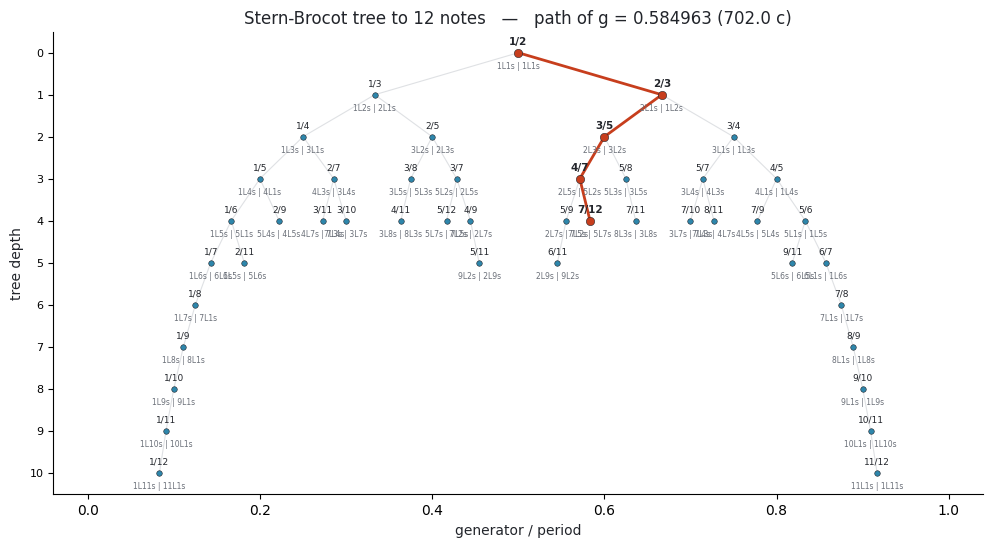

In [4]:
fig, ax = M.plot_stern_brocot(12, highlight_generator=math.log2(FIFTH))
plt.show()

In [5]:
g = M.generator_fraction(FIFTH)
print("path down the tree:", M.sb_path(g, 53))
print("MOS cardinalities: ", M.mos_cardinalities(g, 53, include_trivial=True))

path down the tree: RLLRRLLL
MOS cardinalities:  [2, 3, 5, 7, 12, 17, 29, 41, 53]


Those cardinalities — 2, 3, 5, 7, 12, 17, 29, 41, 53 — are the semiconvergent
denominators of `log2(3/2)`, and they are exactly the numbers of notes at which a stack
of fifths has only two step sizes. They are also the historically important divisions of
the octave, which is not a coincidence.

## 3. A generator's family

Each scale in a family is a subset of the next one down: they are all the same generator
chain, cut at different lengths.

In [6]:
family = M.mos_family(FIFTH, max_cardinality=29)
pd.DataFrame([
    {
        "notes": s.cardinality,
        "signature": s.signature,
        "word": s.word,
        "L ¢": round(s.step_cents[0], 2),
        "s ¢": round(s.step_cents[1], 2),
        "R": round(s.hardness, 3),
        "proper": s.is_proper,
    }
    for s in family
])

,notes,signature,word,L ¢,s ¢,R,proper
0,3,2L1s,sLL,498.04,203.91,2.442,False
1,5,2L3s,ssLsL,294.13,203.91,1.442,True
2,7,5L2s,LLLsLLs,203.91,90.22,2.260,False
3,12,5L7s,LsLsLssLsLss,113.69,90.22,1.260,True
4,17,12L5s,sLLsLLsLLLsLLsLLL,90.22,23.46,3.846,False
5,29,12L17s,ssLsLssLsLssLsLsLssLsLssLsLsL,66.76,23.46,2.846,False


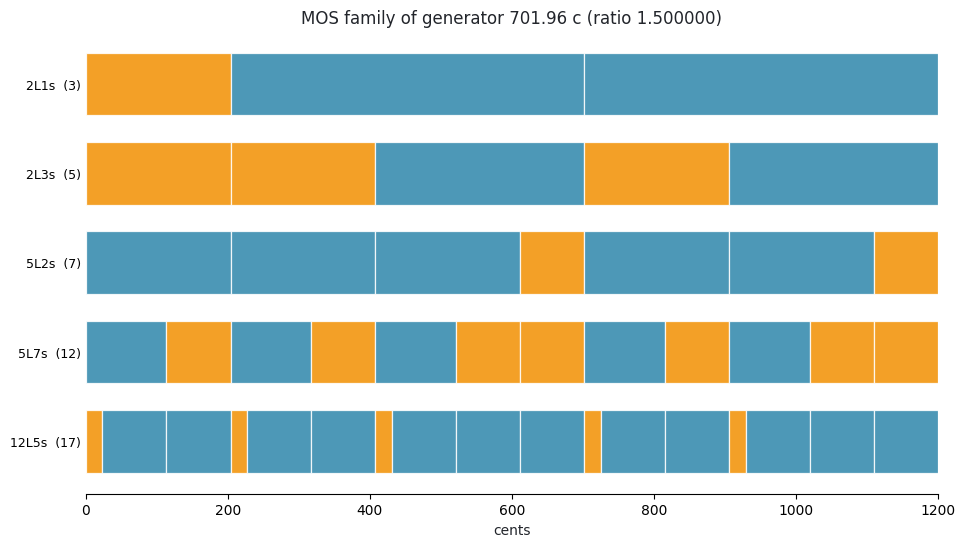

In [7]:
fig, ax = M.plot_mos_family(FIFTH, max_cardinality=17)
plt.show()

## 4. One scale, up close

`MOSScale` keeps the abstract structure (`5L2s`) and the concrete tuning (a 702-cent
generator) as separate coordinates — the two-part choice the labyrinth affords.

In [8]:
d = M.mos(FIFTH, 7)
print(d.summary())

5L2s  (7 notes)   LLLsLLs
  generator       701.955 c  (ratio 1.500000, g = 0.584963)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 203.910 c,  s = 90.225 c,  R = 2.2600
  valid range    4/7 .. 3/5   (685.7 .. 720.0 c)
  coherent over  4/7 .. 7/12   -> IMPROPER at this tuning
  landmarks      equalized 4/7 = 7-EDO,  s->0 at 3/5 = 5-EDO,  L->0 at 1/2 = 2-EDO
  inverse        2L5s
  embedded in    12 notes (equal at 7/12)


Note the last two lines of that summary. Pythagorean tuning is **improper**: its
generator, 702 ¢, is outside the diatonic's coherent range of 4/7 … 7/12 (685.7 … 700 ¢).
Concretely, the Pythagorean major third is wider than the diminished fourth, so generic
and specific interval sizes stop agreeing. Flatten the fifth into meantone and coherence
returns.

In [9]:
pd.DataFrame([
    {
        "tuning": name,
        "generator ¢": round(s.generator_cents, 3),
        "L ¢": round(s.step_cents[0], 2),
        "s ¢": round(s.step_cents[1], 2),
        "R = L/s": round(s.hardness, 3),
        "proper": s.is_proper,
    }
    for name, s in [
        ("7-EDO (equalized)", M.MOSScale.from_signature(5, 2, tuning="equalized")),
        ("19-EDO", M.MOSScale.from_signature(5, 2, tuning=19)),
        ("31-EDO (meantone)", M.MOSScale.from_signature(5, 2, tuning=31)),
        ("12-EDO", M.MOSScale.from_signature(5, 2, tuning=12)),
        ("Pythagorean", M.mos(FIFTH, 7)),
        ("5-EDO (s vanishes)", M.MOSScale.from_signature(5, 2, tuning="middle").retune(0.5999)),
    ]
])

,tuning,generator ¢,L ¢,s ¢,R = L/s,proper
0,7-EDO (equalized),685.714,171.43,171.43,1.000,True
1,19-EDO,694.737,189.47,126.32,1.500,True
2,31-EDO (meantone),696.774,193.55,116.13,1.667,True
3,12-EDO,700.000,200.00,100.00,2.000,True
4,Pythagorean,701.955,203.91,90.22,2.260,False
5,5-EDO (s vanishes),719.880,239.76,0.60,399.600,False


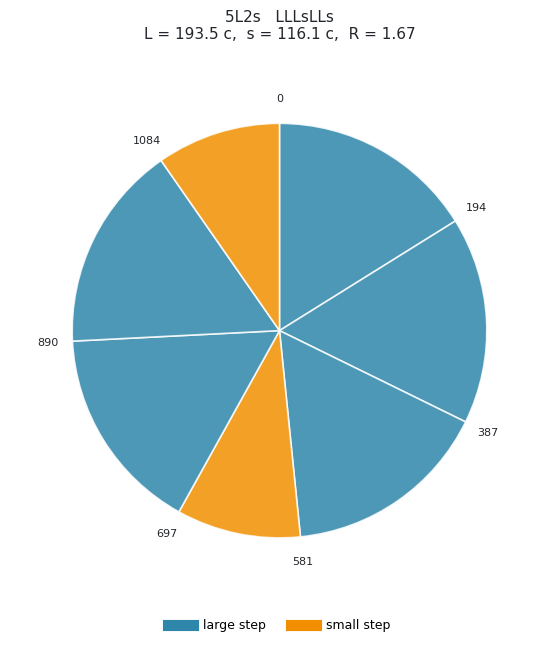

In [10]:
fig, ax = M.plot_scale_wheel(M.MOSScale.from_signature(5, 2, tuning=31))
plt.show()

The keyboard is drawn with key widths proportional to the step above each tone
(Milne et al. Fig. 8), so the maximally even distribution of large and small steps is
visible directly.

## 5. Landmarks: how the two steps trade off

As the generator moves, the two step sizes co-vary, always summing to the period, and
they pass through three distinguished tunings (Milne et al. §2, "Landmark equal
tunings"). One where they become equal — where the scale meets its inverse — and one on
each side where a step size shrinks to zero.

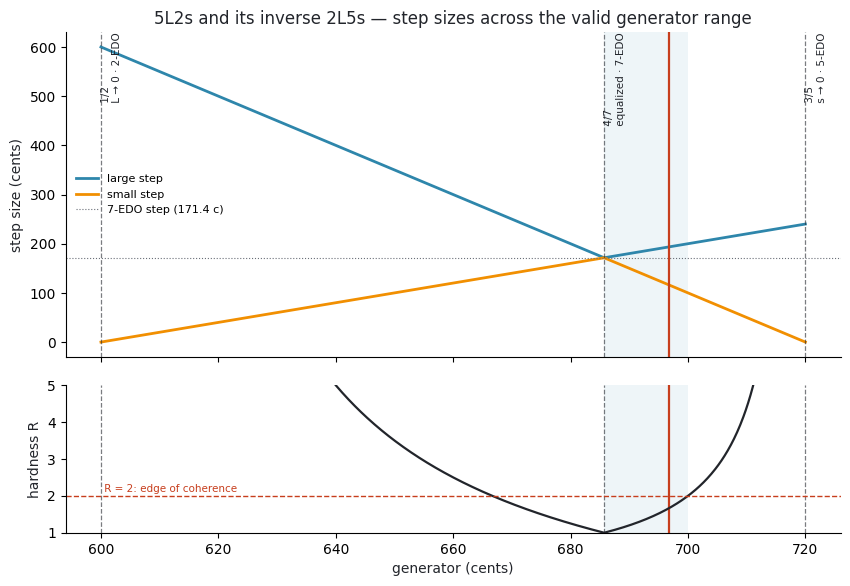

In [11]:
fig, axes = M.plot_step_covariation(5, 2, mark=M.MOSScale.from_signature(5, 2, tuning=31).generator)
plt.show()

In [12]:
lm = M.mos_landmarks(5, 2)
print(f"equalized      {lm.equalized}  = {lm.equalized_edo}-EDO")
print(f"small vanishes {lm.small_vanishes}  = {lm.small_vanishes_edo}-EDO")
print(f"large vanishes {lm.large_vanishes}  = {lm.large_vanishes_edo}-EDO")
print(f"embedded in    {M.embedding(5, 2)[0]} notes at {M.embedding(5, 2)[1]}")
print(f"coherent over  {M.coherence_range(5, 2)[0]} … {M.coherence_range(5, 2)[1]}")

equalized      4/7  = 7-EDO
small vanishes 3/5  = 5-EDO
large vanishes 1/2  = 2-EDO
embedded in    12 notes at 7/12
coherent over  4/7 … 7/12


## 6. Modes, and why exactly one note moves

A scale presupposes periodicity, so all its rotations are the same scale. A *mode* is a
choice of finalis. The modes of a well-formed scale are **parsimonious**: neighbouring
modes in the brightness order differ by a single tone, displaced by the chroma `L − s`.

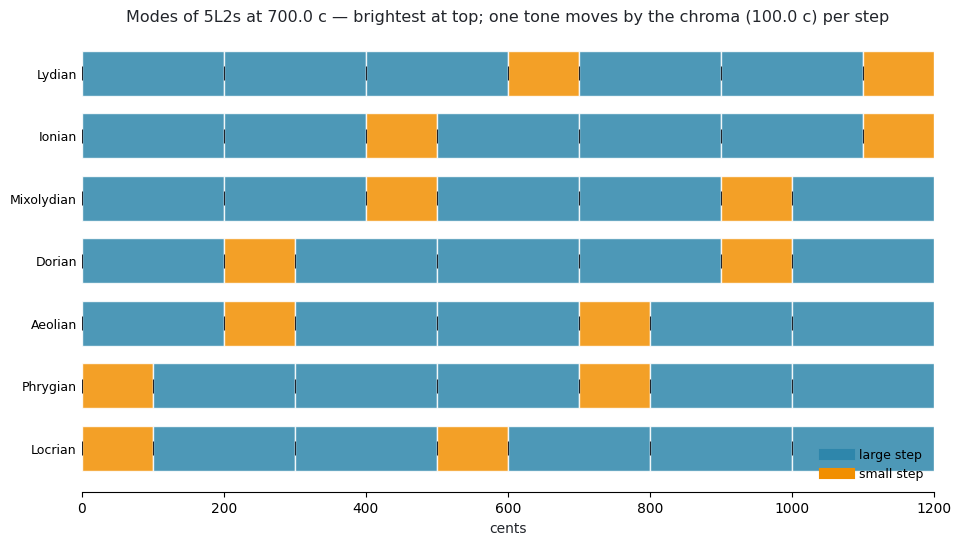

In [13]:
d12 = M.MOSScale.from_signature(5, 2, tuning=12)
fig, ax = M.plot_modes(d12)
plt.show()

In [14]:
for brighter, darker, moved in M.parsimony_chain(d12):
    step, mine, theirs = moved[0]
    print(f"{brighter.name:11s} -> {darker.name:11s}   degree {step} : "
          f"{mine:7.1f} ¢ -> {theirs:7.1f} ¢   ({mine - theirs:+.1f} ¢)")

Lydian      -> Ionian        degree 3 :   600.0 ¢ ->   500.0 ¢   (+100.0 ¢)
Ionian      -> Mixolydian    degree 6 :  1100.0 ¢ ->  1000.0 ¢   (+100.0 ¢)
Mixolydian  -> Dorian        degree 2 :   400.0 ¢ ->   300.0 ¢   (+100.0 ¢)
Dorian      -> Aeolian       degree 5 :   900.0 ¢ ->   800.0 ¢   (+100.0 ¢)
Aeolian     -> Phrygian      degree 1 :   200.0 ¢ ->   100.0 ¢   (+100.0 ¢)
Phrygian    -> Locrian       degree 4 :   700.0 ¢ ->   600.0 ¢   (+100.0 ¢)


Milne et al. §4 formalise this as a free commutative group ℤ² of rank 2, generated by two
commuting transformations: **σ** (diatonic transposition — same notes, finalis one step
higher) and **τ** (chromatic transposition — same finalis, origin one generator
sharpwards). Each mode occupies a fundamental frame in that lattice.

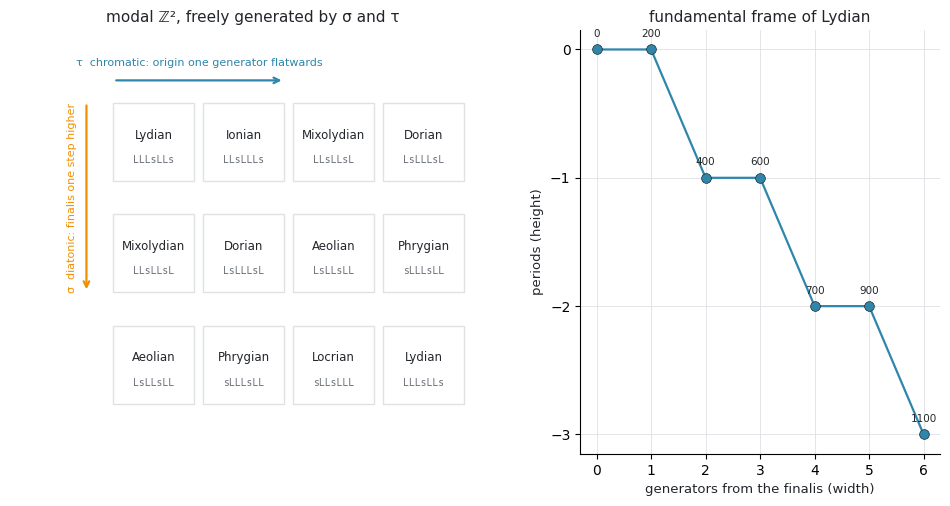

In [15]:
fig, axes = M.plot_mode_lattice(d12, width=4, height=3)
plt.show()

## 7. Named temperaments

Milne et al. §4 overlay named rank-2 temperaments on the labyrinth as radial lines at
their optimal generators. Here those generators are *computed* from each temperament's
comma — find the saturated integer mapping that annihilates the comma, reduce it to
Hermite normal form, then solve a Tenney-weighted least squares — so the numbers are
derived rather than copied, and can be checked against published tables.

In [16]:
temps = M.all_temperaments()
pd.DataFrame([
    {
        "name": name,
        "comma": str(t.comma),
        "periods/oct": t.periods_per_octave,
        "period ¢": round(t.period_cents, 2),
        "POTE gen ¢": round(t.pote_generator_cents, 3),
        "max prime error ¢": round(t.max_error, 3),
    }
    for name, t in temps.items()
]).sort_values("max prime error ¢").reset_index(drop=True)

,name,comma,periods/oct,period ¢,POTE gen ¢,max prime error ¢
0,schismatic,32805/32768,1,1200.0,701.736,0.236
1,amity,1600000/1594323,1,1200.0,339.519,0.359
2,hanson,15625/15552,1,1200.0,317.007,1.021
3,sensipent,78732/78125,1,1200.0,756.942,1.081
4,wuerschmidt,393216/390625,1,1200.0,812.201,1.420
5,compton,531441/524288,12,100.0,84.882,1.955
6,tetracot,20000/19683,1,1200.0,176.160,2.158
7,srutal,2048/2025,2,600.0,104.898,3.414
8,meantone,81/80,1,1200.0,696.239,4.741
9,magic,3125/3072,1,1200.0,380.058,5.814


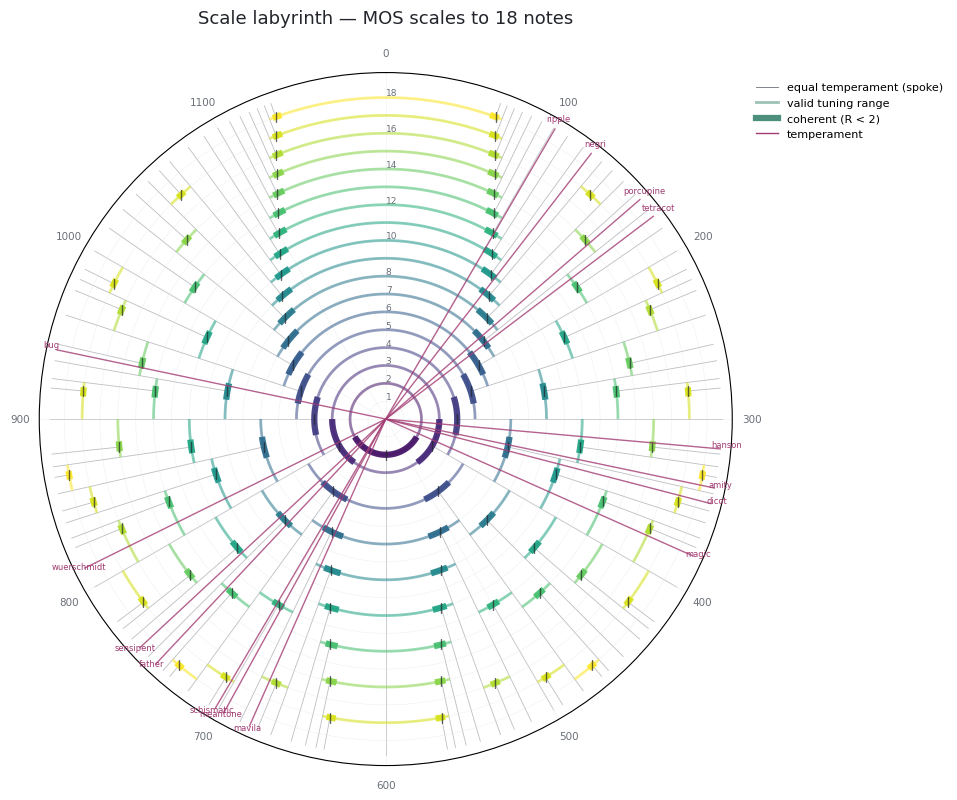

In [17]:
fig, ax = M.plot_labyrinth(18, temperaments=True)
plt.show()

## 8. Where the labyrinth approximates just intonation

Milne et al. §1 point at this use directly. Each cell is the mean cents error from a
5-limit just interval to the nearest degree of the MOS at that (generator, cardinality);
grey means there is no MOS there at all, which is most of the plane.

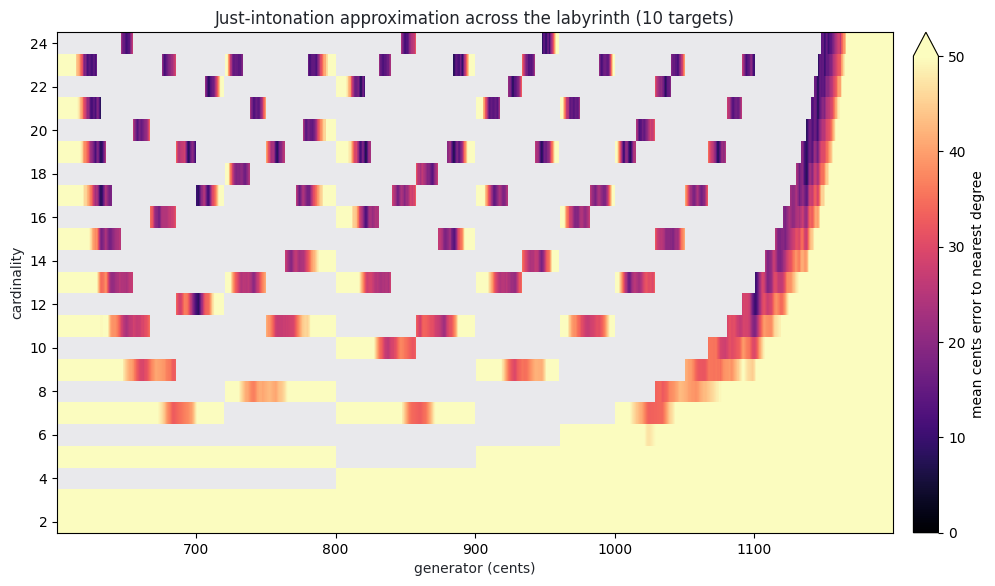

In [18]:
fig, ax = M.plot_ji_landscape(max_cardinality=24, resolution=1600)
plt.show()

## 9. From a biosignal to a scale

Everything above is music theory. This is the part the paper does not have.

The labyrinth is a *search space* with three coordinates — generator, cardinality and
period — and `fit_mos` searches it. Candidate generators come from the signal itself
(every observed ratio, and every ratio between ratios), plus a background grid. Only the
cardinalities that are genuinely MOS for a given generator are considered. The objective
is amplitude-weighted mean cents error from each peak ratio to its nearest scale degree,
plus a penalty for surplus notes — without which the biggest scale allowed would always
win by brute coverage.

There is a fourth, nuisance coordinate too: each candidate scale is free to *transpose*
itself onto the data. A scale and its transpositions are the same scale, so this is the
right comparison — and it matters. A stack of fifths is the pentatonic, but only in one
of the pentatonic's five modes; pin every candidate to a 1/1 root and the answer is
missed.

Start with a signal whose peaks really are a stack of fifths, buried in noise.

In [19]:
rng = np.random.default_rng(7)
sf = 1000.0
t = np.arange(0, 30, 1 / sf)

base = 5.0
partials = [base, base * 1.5, base * 2.25, base * 3.375, base * 2.0]
amps = [1.0, 0.9, 0.75, 0.5, 0.65]
signal = sum(a * np.sin(2 * np.pi * f * t) for a, f in zip(amps, partials))
signal = signal + 0.25 * rng.standard_normal(t.size)

from biotuner.biotuner_object import compute_biotuner

bt = compute_biotuner(sf, peaks_function="FOOOF", precision=0.1)
bt.peaks_extraction(signal, min_freq=2, max_freq=40, n_peaks=5)
print("peaks (Hz):", np.round(bt.peaks, 3))
print("ratios:    ", np.round(bt.peaks_ratios, 5))

peaks (Hz): [ 5.    7.5   9.99 11.25 16.88]
ratios:     [1.125   1.12533 1.12613 1.332   1.5     1.50044 1.688   1.68969 1.998  ]


In [20]:
fit = bt.fit_mos(max_cardinality=16)
print(M.explain_fit(fit, bt.peaks_ratios))

2L3s  (5 notes)   ssLsL
  generator       702.727 c  (ratio 1.500669, g = 0.585606)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 291.820 c,  s = 205.453 c,  R = 1.4204
  valid range    1/2 .. 3/5   (600.0 .. 720.0 c)
  coherent over  4/7 .. 3/5   -> proper
  landmarks      equalized 3/5 = 5-EDO,  s->0 at 1/2 = 2-EDO,  L->0 at 2/3 = 3-EDO
  inverse        3L2s
  embedded in    7 notes (equal at 4/7)
  fit            error 0.577 c (weighted mean), max 1.149 c, rms 0.681 c
  chance         60.000 c for 5 degrees;  improvement 103.92x;  evidence 4.54 SE below chance
  coverage       100.0% of weight within tolerance;  7 targets, 0 unused degrees;  score 0.577
  folded         2 ratio(s) merged into a pitch class already present (an octave is not a second target)
  targets        each ratio and where it landed
       1.125000 -> degree  4 (  908.18 c,   -0.58 c)
       1.126126 -> degree  4 (  908.18 c,   +1.15 c)
       1.332000 -> degree  0 (    0.00 c,   +0.00 c)
  

`improvement` is the number worth reading. A scale with many notes will always sit close
to any set of ratios, so the error alone means little; `improvement` divides it by the
error a *random* set of ratios would get against a scale of that size. A value near 1 is
no better than chance.

It is not the last word, though: a derivation that yields only two ratios can post
an enormous `improvement` for no good reason, which section 11 takes apart. With
seven targets against a five-note scale, nothing here is being flattered.

In [21]:
pd.DataFrame([
    {
        "rank": i + 1,
        "signature": f.signature,
        "notes": f.scale.cardinality,
        "generator ¢": round(f.scale.generator_cents, 2),
        "error ¢": round(f.error_cents, 3),
        "chance ¢": round(f.chance_error_cents, 2),
        "improvement": round(f.improvement, 1) if np.isfinite(f.improvement) else "exact",
        "score": round(f.score, 3),
    }
    for i, f in enumerate(bt.mos_fits)
])

,rank,signature,notes,generator ¢,error ¢,chance ¢,improvement,score
0,1,2L3s,5,702.73,0.577,60.00,103.9,0.577
1,2,5L2s,7,702.63,0.577,42.86,74.2,0.577
2,3,5L4s,9,951.36,0.577,33.33,57.7,2.577
3,4,7L3s,10,848.66,0.577,30.00,52.0,3.577
4,5,1L9s,10,1099.72,2.373,30.00,12.6,5.373


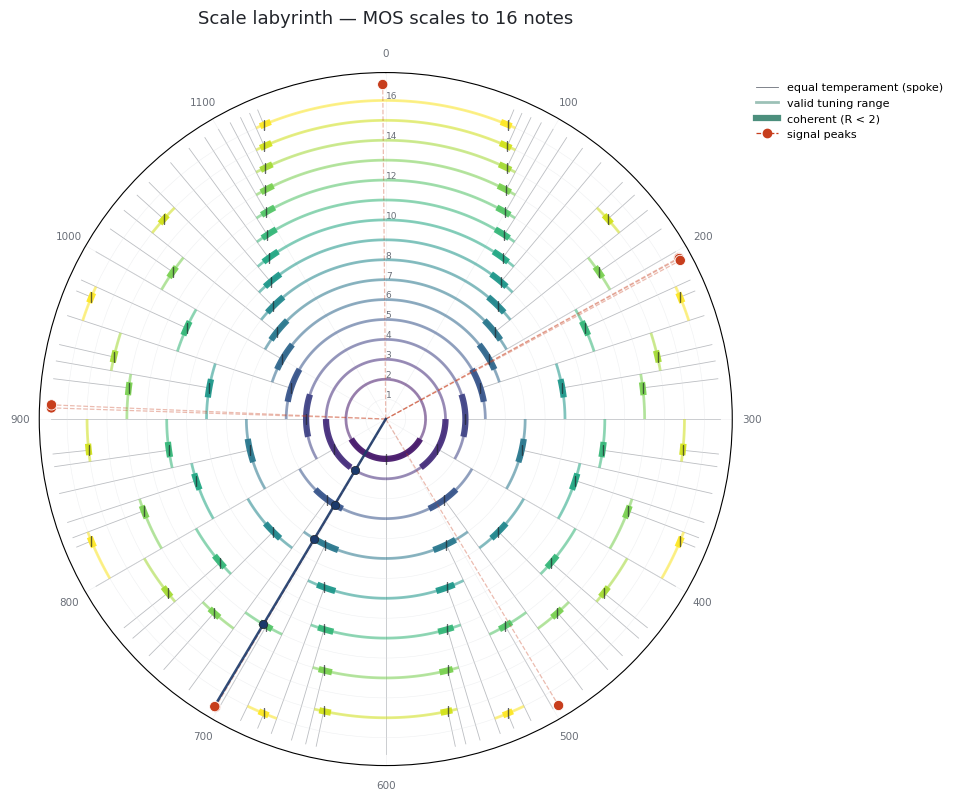

In [22]:
fig, ax = bt.plot_labyrinth(16)
plt.show()

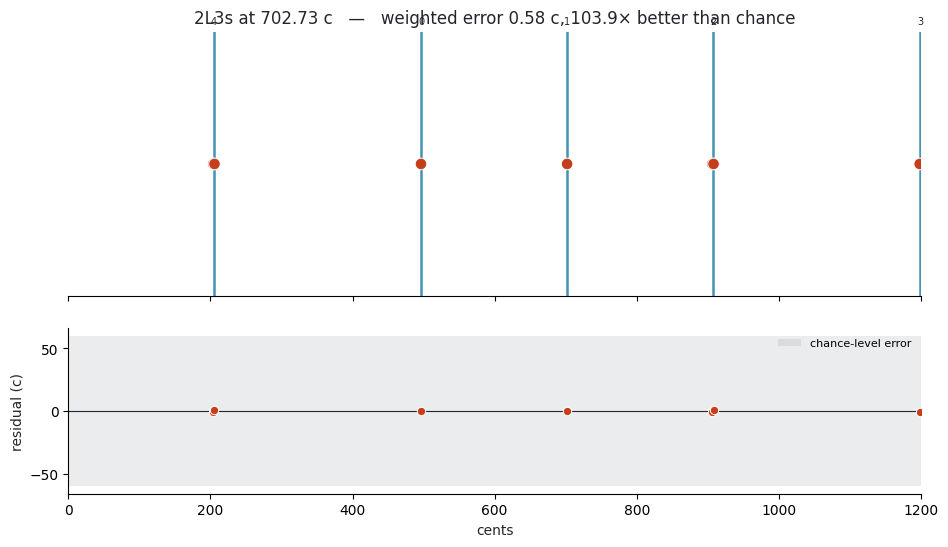

In [23]:
fig, axes = M.plot_mos_fit(fit, bt.peaks_ratios)
plt.show()

The fitted scale is a tuning like any other, so it flows into the rest of the toolbox:

In [24]:
print("fitted structure :", fit.signature, "at", round(fit.scale.generator_cents, 2), "¢")
print("transposed by    :", round(fit.offset * 1200, 2), "¢  -> mode:",
      fit.mode.name if fit.mode else "(not a scale tone)")
print("as a tuning      :", np.round(bt.get_tuning("mos"), 5))

fitted structure : 2L3s at 702.73 ¢
transposed by    : 496.31 ¢  -> mode: mode 3 of 2L3s
as a tuning      : [1.      1.126   1.33274 1.50067 1.68976]


In [25]:
print(fit.scale.to_scala(write=False)[:400])

! Scale produced by Biotuner. For tuning yoshimi or zynaddsubfx,
! only include the portion below the final '!'
!
2L3s
  5
!
205.45329
410.90658
702.72665
908.17994
1200.00000


## 10. A path through the labyrinth

Fit each window of a recording independently and the result is a *trajectory*: the scale
structure drifting, or holding, as the signal evolves. Here is a signal that deliberately
changes its harmonic structure halfway through.

In [26]:
half = t.size // 2
seg_a = sum(a * np.sin(2 * np.pi * f * t[:half])
            for a, f in zip(amps, partials))
# Second half: a stack of ~316-cent minor thirds instead of fifths.
third = 2 ** (316 / 1200)
partials_b = [base * third**k for k in range(4)] + [base * 2]
seg_b = sum(a * np.sin(2 * np.pi * f * t[half:])
            for a, f in zip(amps, partials_b))
switching = np.concatenate([seg_a, seg_b]) + 0.25 * rng.standard_normal(t.size)

traj = M.mos_trajectory(
    switching, sf, window_sec=6.0, step_sec=3.0,
    peaks_function="FOOOF", precision=0.1, n_peaks=5, max_cardinality=16,
)
pd.DataFrame([
    {
        "window": i,
        "signature": f.signature if f else None,
        "generator ¢": round(f.scale.generator_cents, 1) if f else None,
        "error ¢": round(f.error_cents, 2) if f else None,
    }
    for i, f in enumerate(traj)
])

C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 10000 is greater than input length  = 6000, using nperseg = 6000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


,window,signature,generator ¢,error ¢
0,0,2L3s,699.6,0.86
1,1,2L3s,702.7,2.31
2,2,5L2s,701.8,0.84
3,3,2L3s,701.7,1.69
4,4,8L3s,759.5,6.68
5,5,4L3s,883.4,1.38
6,6,4L3s,883.8,1.65
7,7,4L3s,883.7,2.40
8,8,4L3s,882.8,2.31


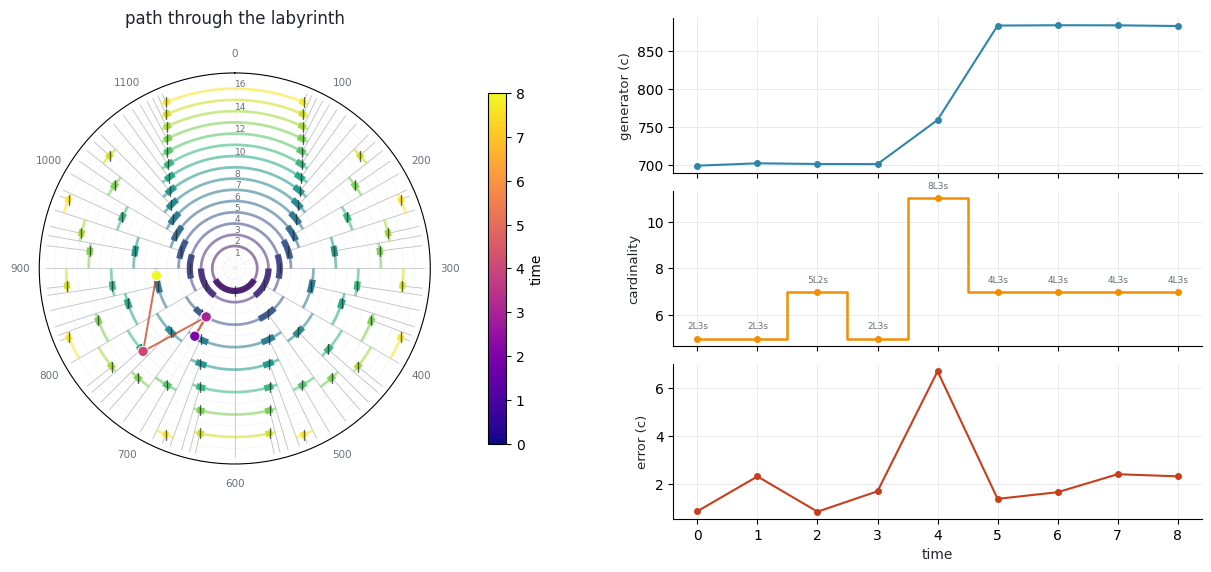

In [27]:
fig, axes = M.plot_mos_trajectory(traj, max_cardinality=16)
plt.show()

## 11. Which derivation? Ask all of them

Section 9 fitted the peak ratios. But `compute_biotuner` turns a signal into ratios
eight different ways — peak ratios, consonant ratios, extended peaks, dissonance-curve
minima, harmonic-entropy minima, an Euler-Fokker genus, a common-harmonic tuning, a
harmonic fit — and they do not agree with each other. Every one of them can feed the
fit, through `source=` on `bt.fit_mos`, `bt.mos_trajectory` and
`M.mos_from_biotuner`; `bt.compare_mos_sources()` runs the whole set at once so they
can be read side by side.

`extended_ratios` is the one source that needs a precursor — `peaks_extension` — so
run that first. Everything else is derived on demand.

In [28]:
bt.peaks_extension(method="harmonic_fit", harm_function="mult", cons_limit=0.1)

comparison = bt.compare_mos_sources(max_cardinality=16)
comparison[[
    "source", "n_ratios", "n_targets", "n_merged", "signature", "cardinality",
    "error_cents", "chance_error_cents", "improvement", "evidence",
    "coverage", "underdetermined",
]].round(3)

,source,n_ratios,n_targets,n_merged,signature,cardinality,error_cents,chance_error_cents,improvement,evidence,coverage,underdetermined
0,peaks_ratios,9.0,7.0,2.0,2L3s,5.0,0.577,60.000,1.039200e+02,4.538,1.000,False
1,extended_ratios,18.0,17.0,1.0,12L1s,13.0,9.949,23.077,2.320000e+00,4.063,0.722,False
2,diss_curve,8.0,8.0,0.0,7L3s,10.0,5.192,30.000,5.779000e+00,4.051,0.875,True
3,euler_fokker,9.0,8.0,1.0,4L7s,11.0,6.932,27.273,3.934000e+00,3.654,0.889,True
4,HE,5.0,5.0,0.0,1L8s,9.0,4.707,33.333,7.082000e+00,3.326,0.800,True
5,cons_ratios,2.0,2.0,0.0,3L1s,4.0,0.000,75.000,5.158593e+07,2.449,1.000,True
6,harm_fit_tuning,37.0,37.0,0.0,3L13s,16.0,16.285,18.750,1.151000e+00,1.385,0.541,False
7,harm_tuning,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None


Read the **`evidence`** column, not `error_cents`.

The smallest error in the table belongs to `cons_ratios`, at a few millionths of a
cent — and it sits near the bottom of the ranking. It derived only two ratios, and a
four-note scale has enough spare degrees to be rotated until both land exactly; that
number measures the scale's slack, not the signal. `improvement` does not rescue the
ranking either, since dividing by the chance error puts the same two-point fit on top
by seven orders of magnitude.

`evidence` is the one that counts how much data the margin below chance was measured
over: `sqrt(3 * n_targets) * (1 - error / chance)`, the number of standard errors the
weighted mean falls below what random ratios would score against a scale of that size.
It self-limits at `sqrt(3n)`, so two targets can never beat 2.45 however exact they
are, while seven exact targets reach 4.58.

At the other end sits `harm_fit_tuning`: the most data in the table and the least
structure, a ladder dense enough that even the largest scale allowed misses nearly
half of it. And a source that *raises* is not quietly dropped — it keeps its row, with
the exception in `reason`.

In [29]:
for _, row in comparison.iterrows():
    if row["reason"]:
        print(f"{row['source']}:\n  {row['reason']}\n")

for src in (comparison.iloc[0]["source"], "cons_ratios"):
    fit_src = M.mos_from_biotuner(bt, source=src, max_cardinality=16)[0]
    print(f"----- {src}")
    print(M.explain_fit(fit_src))
    print()

harm_tuning:
  ValueError: harmonic_tuning() needs harmonic positions and this object has none: self.all_harmonics is only measured by peaks_extraction(peaks_function='harmonic_recurrence'), and peaks_function is 'FOOOF'. Either pass them explicitly (list_harmonics=[1, 2, 3, ...]), re-extract with peaks_function='harmonic_recurrence', or use harmonic_fit_tuning() / get_tuning('harm_fit_tuning'), which derives harmonic positions from the peaks themselves.



----- peaks_ratios
2L3s  (5 notes)   ssLsL
  generator       702.727 c  (ratio 1.500669, g = 0.585606)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 291.820 c,  s = 205.453 c,  R = 1.4204
  valid range    1/2 .. 3/5   (600.0 .. 720.0 c)
  coherent over  4/7 .. 3/5   -> proper
  landmarks      equalized 3/5 = 5-EDO,  s->0 at 1/2 = 2-EDO,  L->0 at 2/3 = 3-EDO
  inverse        3L2s
  embedded in    7 notes (equal at 4/7)
  fit            error 0.577 c (weighted mean), max 1.149 c, rms 0.681 c
  chance         60.000 c for 5 degrees;  improvement 103.92x;  evidence 4.54 SE below chance
  coverage       100.0% of weight within tolerance;  7 targets, 0 unused degrees;  score 0.577
  folded         2 ratio(s) merged into a pitch class already present (an octave is not a second target)



----- cons_ratios
3L1s  (4 notes)   sLLL
  generator       849.022 c  (ratio 1.632993, g = 0.707519)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 350.978 c,  s = 147.067 c,  R = 2.3865
  valid range    2/3 .. 3/4   (800.0 .. 900.0 c)
  coherent over  5/7 .. 3/4   -> IMPROPER at this tuning
  landmarks      equalized 3/4 = 4-EDO,  s->0 at 2/3 = 3-EDO,  L->0 at 1 = 1-EDO
  inverse        1L3s
  embedded in    7 notes (equal at 5/7)
  fit            error 0.000 c (weighted mean), max 0.000 c, rms 0.000 c
  chance         75.000 c for 4 degrees;  improvement 51585934.02x;  evidence 2.45 SE below chance
  coverage       100.0% of weight within tolerance;  2 targets, 2 unused degrees;  score 2.000
  UNDERDETERMINED  2 targets for 4 degrees: a scale with spare notes can be rotated onto any data, so this error is not evidence



Two things happen to a ratio list before any scale is tried.

**The ratios are folded into the period.** A scale has no way to tell `1/1` from
`2/1` — they are one degree — so ratios naming the same pitch class to within
`FOLD_TOLERANCE_CENTS` (1 ¢) are merged into one target and their weights summed. The
`n_ratios` → `n_targets` columns above show what was actually fitted: `euler_fokker`
lists both 1.0 and 2.0, and `peaks_ratios` contains pairs half a cent apart. Because
the weights are summed rather than dropped, the weighted mean error does not move at
all — folding is not an accuracy fix. It corrects the *sample size*, and with it the
surplus-note penalty and `evidence`.

**A fit with more degrees than targets is flagged, not dropped.** A scale with spare
notes can be rotated until everything lands on something, so its error is not
evidence of anything — but it may still be the right structure, and five peaks simply
cannot produce twelve targets. `is_underdetermined` says so out loud instead of
hiding the fit or hiding the problem.

And `source="mos"` is refused: `get_tuning("mos")` hands back the ratios of an earlier
fit, so fitting a scale to them guarantees the answer in advance.

In [30]:
ladder = [1.0, 9 / 8, 5 / 4, 3 / 2, 2.0]      # the 2/1 repeats the 1/1
for label, kwargs in [("folded (default)", {}), ("fold=False", {"fold": False})]:
    f = M.fit_mos(ladder, max_cardinality=16, **kwargs)[0]
    print(f"{label:17s} {f.signature:5s}  targets {f.n_targets} (merged {f.n_merged})"
          f"  error {f.error_cents:.13f} ¢  evidence {f.evidence:.3f}"
          f"  underdetermined {f.is_underdetermined}")

one = M.best_mos([1.5], max_cardinality=16)
print(f"\none ratio -> {one.signature} at {one.error_cents:.3f} ¢, "
      f"improvement {one.improvement}")
print(M.explain_fit(one).splitlines()[-1].strip())

try:
    bt.fit_mos(source="mos")
except ValueError as exc:
    print(f"\nsource='mos' -> ValueError: {str(exc).split(':')[0]}")

folded (default)  2L3s   targets 4 (merged 1)  error 3.2259449169634 ¢  evidence 3.278  underdetermined True


fold=False        2L3s   targets 5 (merged 0)  error 3.2259449169634 ¢  evidence 3.665  underdetermined False



one ratio -> 1L3s at 0.000 ¢, improvement inf
UNDERDETERMINED  1 target for 4 degrees: a scale with spare notes can be rotated onto any data, so this error is not evidence

source='mos' -> ValueError: source='mos' would fit a moment-of-symmetry scale to a moment-of-symmetry scale


## 12. Fourier Scratching

Milne et al. §5's performance technique. A virtual robot has *n* fingers striking a
continuous circular keyboard at a fixed pulse; finger *k*'s state is a complex number
whose magnitude is loudness and whose phase is position on the circle. The player
manipulates the **DFT** of that state vector rather than the fingers directly — one
gesture reshapes the whole pattern.

The elementary play states are the pure partials. Milne et al. §5 say that for a coherent
well-formed scale the first partial plays every tone exactly once, in ascending scalar
order — but that turns out to be a property of a particular **mode**, not of the scale.
The keys are as wide as the steps above their tones, so evenly spaced fingers only land
one-per-key in the rotation whose word is the Christoffel word. In any other mode two
fingers share a key and another key is missed.

In [31]:
naive = d12.mode(0)                    # Lydian — the brightest mode
proper = M.christoffel_mode(d12)       # Locrian — the one Fig. 8 needs

for label, mode in [("mode 0 " + naive.name, naive), ("christoffel " + proper.name, proper)]:
    degrees = [e.degree for e in M.to_events(M.partial(7, 1), mode)]
    print(f"{label:24s} {mode.word}   degrees {degrees}   distinct {len(set(degrees))}")

mode 0 Lydian            LLLsLLs   degrees [0, 0, 1, 2, 3, 4, 5]   distinct 6
christoffel Locrian      sLLsLLL   degrees [0, 1, 2, 3, 4, 5, 6]   distinct 7


In [32]:
state = M.partial(7, 1)
events = M.to_events(state, proper)
print("degrees struck, in finger order:", [e.degree for e in events])
print("frequencies (Hz):", [round(f, 2) for f in M.to_frequencies(events, fund=250)])

degrees struck, in finger order: [0, 1, 2, 3, 4, 5, 6]
frequencies (Hz): [250.0, 264.87, 297.3, 333.71, 353.55, 396.85, 445.45]


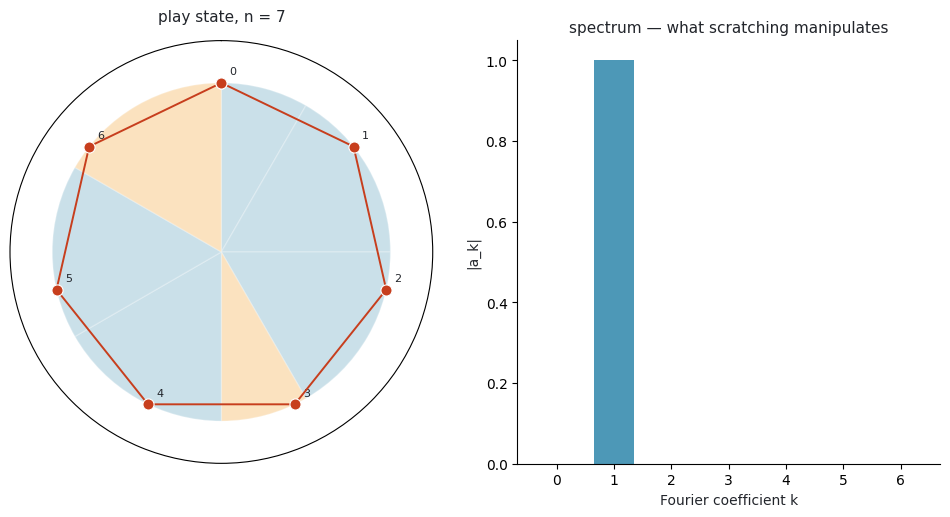

In [33]:
fig, axes = M.plot_play_state(state, proper)
plt.show()

Higher partials with an index coprime to *n* generate complete generic interval cycles —
every tone still struck once, but in a different order.

In [34]:
for k in range(1, 8):
    degrees = [e.degree for e in M.to_events(M.partial(7, k), proper)]
    coprime = math.gcd(k, 7) == 1
    print(f"partial {k}  coprime={str(coprime):5s}  degrees {degrees}  "
          f"distinct {len(set(degrees))}")

partial 1  coprime=True   degrees [0, 1, 2, 3, 4, 5, 6]  distinct 7
partial 2  coprime=True   degrees [0, 2, 4, 6, 1, 3, 5]  distinct 7
partial 3  coprime=True   degrees [0, 3, 6, 2, 5, 1, 4]  distinct 7
partial 4  coprime=True   degrees [0, 4, 1, 5, 2, 6, 3]  distinct 7
partial 5  coprime=True   degrees [0, 5, 3, 1, 6, 4, 2]  distinct 7
partial 6  coprime=True   degrees [0, 6, 5, 4, 3, 2, 1]  distinct 7
partial 7  coprime=False  degrees [0, 0, 0, 0, 0, 0, 0]  distinct 1


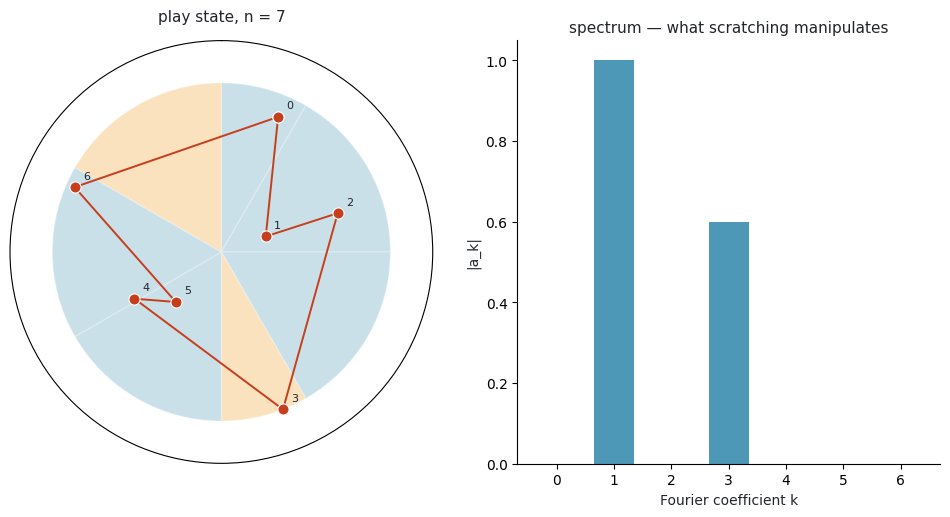

In [35]:
# "Scratching": move one Fourier coefficient and the whole play state responds.
scratched = state.scratch(3, magnitude=0.6, phase=1.1)
fig, axes = M.plot_play_state(scratched, proper)
plt.show()

## 13. Dynamic Tonality: matching the timbre to the scale

Milne et al. §6. Intervals inside a dynamically tuned well-formed scale can be far from
any low integer ratio, so a plain harmonic timbre sounds out of tune against them.
Dynamic Tonality retunes the *timbre* instead: each partial's pitch becomes a linear
combination of the period and generator pitch heights, so partials of different tones
coincide exactly as the scale's own intervals do.

In [36]:
mt = M.MOSScale.from_signature(5, 2, tuning=31)
pd.DataFrame([
    {
        "harmonic": p.harmonic,
        "α (periods)": p.alpha,
        "β (generators)": p.beta,
        "just": round(p.just_ratio, 5),
        "retuned": round(p.ratio, 5),
        "error ¢": round(p.error_cents, 2),
    }
    for p in M.matched_partials(mt, n_partials=10)
])

,harmonic,α (periods),β (generators),just,retuned,error ¢
0,1,0,0,1.0,1.00000,0.00
1,2,1,0,2.0,2.00000,0.00
2,3,1,1,3.0,2.99104,-5.18
3,4,2,0,4.0,4.00000,0.00
4,5,0,4,5.0,5.00226,0.78
5,6,2,1,6.0,5.98207,-5.18
6,7,-3,10,7.0,6.99562,-1.08
7,8,3,0,8.0,8.00000,0.00
8,9,2,2,9.0,8.94629,-10.36
9,10,1,4,10.0,10.00452,0.78


Harmonic 3 maps to one period plus one generator, and harmonic 5 to four generators —
which is what "meantone" means: four fifths, octave-reduced, stand in for a just major
third.

The payoff is measurable. For a scale tuned well away from 12-EDO, matched partials give
lower total sensory dissonance than harmonic ones:

In [37]:
rows = []
for label, scale in [
    ("5L2s @ 714 ¢", M.MOSScale.from_signature(5, 2, tuning=0.5952)),
    ("5L2s @ 31-EDO", mt),
    ("4L3s", M.MOSScale.from_signature(4, 3, tuning="central")),
    ("7L4s", M.MOSScale.from_signature(7, 4, tuning="central")),
]:
    adv = M.dissonance_advantage(scale, n_partials=8)
    rows.append({
        "scale": label,
        "harmonic partials": round(adv["harmonic"], 3),
        "matched partials": round(adv["matched"], 3),
        "reduction": round(adv["reduction"], 3),
        "reduction %": round(adv["reduction_pct"], 1),
    })
pd.DataFrame(rows)

,scale,harmonic partials,matched partials,reduction,reduction %
0,5L2s @ 714 ¢,21.332,19.924,1.408,6.6
1,5L2s @ 31-EDO,22.451,21.704,0.747,3.3
2,4L3s,24.831,24.851,-0.020,-0.1
3,7L4s,70.877,70.900,-0.023,-0.0


## 14. Interactive exploration

Two interactive surfaces, both needing `pip install biotuner[interactive]`.

`labyrinth_plotly` gives every arc its own hover card — signature, valid range, landmark
EDOs, coherence, embedding — and exports to a standalone HTML file:

```python
fig = M.labyrinth_plotly(18, peaks=bt.peaks_ratios, highlight=fit.scale, temperaments=True)
fig.write_html("labyrinth.html")
fig
```

`mos_explorer` is the instrument Milne et al. designed the labyrinth to be. Drag the
generator and the family recomputes, the wheel redraws, the summary updates and the fit
against your signal is re-scored live:

```python
M.mos_explorer(bt)
```

`fit_explorer` steps through the ranked fits so a close second can be inspected rather
than taken on trust, and `scratch_explorer` puts a slider on every Fourier coefficient:

```python
M.fit_explorer(bt.peaks_ratios)
M.scratch_explorer(proper)
```

## Where to look next

| module | contents |
| --- | --- |
| `mos.theory` | Stern–Brocot, landmarks, Christoffel words — standard library only |
| `mos.scale` | `MOSScale`, the central object |
| `mos.modes` | modes, brightness, the ℤ² height–width lattice |
| `mos.metrics` | Myhill's property, propriety, evenness, JI error |
| `mos.temperaments` | commas → rank-2 mappings → optimal generators |
| `mos.derive` | biosignal → MOS: fitting and trajectories |
| `mos.fourier` | Fourier Scratching play states |
| `mos.timbre` | Dynamic Tonality partial matching |
| `mos.plotting` | the labyrinth and friends |
| `mos.interactive` | Plotly and ipywidgets explorers |